In [1]:
%matplotlib widget
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import matplotlib.image as mpimg
from matplotlib.patches import Polygon

In [2]:
import pandas as pd
import json
import datetime as dt
import numpy as np

# -------------------------- LOAD DATA --------------------------- #

BUILDING_FILENAME: str = "../data/buildings.json"
buildings_df: pd.DataFrame = pd.read_json(BUILDING_FILENAME).set_index("building_id")




GAME_FILENAME: str = "../data/savefile_04_events.json"


# -------------------------- LOAD DATA --------------------------- #

# 1. Load JSON
with open(GAME_FILENAME, mode="r") as file:
    game_data: json = json.load(file)

# 2. Extract top-level metadata
player_id: str = game_data["playerId"]
save_time: dt.datetime = dt.datetime.strptime(game_data["saveDateTime"], "%Y-%m-%d %H:%M:%S")
game_duration: float = float(game_data["challengesSaveObject"]["challengesList"][0]["gameTimer"])

# -------------------------- CHALLENGE DATAFRAME --------------------------- #

# 3. Build rows from the list
challenge_data_rows: list[dict] = []

challenge_id: str = game_data["challengesSaveObject"]["challengesList"][0]["challengeId"]
challenge_duration: float = float(game_data["challengesSaveObject"]["challengesList"][0]["challengeDuration"])

for entry in game_data["challengesSaveObject"]["challengesList"][0]["attemptsList"]:
    challenge_data_rows.append({
        "start_time": float(entry["startTime"]),
        "challenge_id": challenge_id,
        "target_building_id": entry["targetBuildingId"],
        "attempt_number": entry["attemptNumber"],
        "attempt_state": entry["state"],
        "attempt_duration": entry["attemptDuration"],
        "challenge_duration": challenge_duration,
        "game_duration": game_duration,
        "player_id": player_id
    })

challenge_df: pd.DataFrame = pd.DataFrame(challenge_data_rows)



challenge_df = challenge_df.drop_duplicates(subset=["challenge_id", "attempt_number"], keep="last")
challenge_df["attempt_duration"] = challenge_df["attempt_duration"].replace(0, np.nan)

# -------------------------- VALIDATON DATAFRAME --------------------------- #

validation_data_rows: list[dict] = []

for entry in game_data["validationManagerSaveObject"]["playerValidationsList"]:
   validation_data_rows.append({
      "time": float(entry["gameTimer"]),
      "validation": entry["playerValidationSaveObject"]["validation"],
      "is_position_correct": entry["playerValidationSaveObject"]["isPositionCorrect"],
      "is_orientation_correct": entry["playerValidationSaveObject"]["isOrientationCorrect"]
   })

validation_df: pd.DataFrame = pd.DataFrame(validation_data_rows)

# -------------------------- GAME_EVENTS DATAFRAME --------------------------- #

game_events_data_rows: list[dict] = []

for entry in game_data["gameEventsManagerSaveObject"]["gameEventsList"]:
      game_events_data_rows.append({
         "time": float(entry["timer"]),
         "actor": entry["eventActor"],
         "verb": entry["eventVerb"],
         "object": entry["eventObject"],
   })

game_events_df: pd.DataFrame = pd.DataFrame(game_events_data_rows)


# -------------------------- GAME EVENTS FUNCTIONS --------------------------- #

def get_index_for_time_in_challenge_df(time: float) -> int:
   """
   Returns the lowest daframe index for a game time.
   If there is no recorded data for this play time, returns '-1'
    """
   try:
      lowest_time_value_index: int = challenge_df[(challenge_df["start_time"] < time)]["start_time"].idxmax()
   except ValueError:
      return -1
   else:
      return lowest_time_value_index


def get_attempt_num_for_time(time: float) -> int:
   """
   Returns the attempt number for a given play time.
   If there is no attempt number for the play time, returns '-1'
   """
   lowest_time_value_index: int = get_index_for_time_in_challenge_df(time)

   if lowest_time_value_index == -1:
      return -1
   else:
      return int(challenge_df.loc[lowest_time_value_index]["attempt_number"]) #  without casting, returns np.int64(2)


def get_target_building_id_for_time(time: float) -> str:
   """
   Returns the attempt number for a given play time.
   If there is no attempt number for the play time, returns '-1'
   """
   lowest_time_value_index: int = get_index_for_time_in_challenge_df(time)

   if lowest_time_value_index == -1:
      return -1
   else:
      return challenge_df.loc[lowest_time_value_index]["target_building_id"] #  casting not required for strings

# TODO: exception for from value
def get_value_for_key_and_time(key: str, time: float) -> str:
   """
   Returns the attempt number for a given play time.
   If there is no attempt number for the play time, returns '-1'
   """
   lowest_time_value_index: int = get_index_for_time_in_challenge_df(time)

   if lowest_time_value_index == -1:
      return -1
   else:
      return challenge_df.loc[lowest_time_value_index][key] #  casting not required for strings


# -------------------------- PLAYER MOVEMENT DATAFRAME --------------------------- #

# 3. Build rows from the list, reshaping position/rotation into tuples
player_movement_rows: list[dict] = []

for entry in game_data["playerSaveObject"]["playerMovementSaveObject"]["playerMovementInfoList"]:
    time: float = float(entry["gameTime"])
    target_building_id: str = get_target_building_id_for_time(time)
    attempt_numnber: int = get_attempt_num_for_time(time)

    player_movement_rows.append({
        "time": time,
        "challenge_id": get_value_for_key_and_time(key="challenge_id", time=time),
        "target_building_id": target_building_id,
        "target_building_name": buildings_df.loc[target_building_id, "name"],
        "attempt_number": attempt_numnber,
        "attempt_state": challenge_df.loc[
                            (challenge_df["challenge_id"] == challenge_id) & (challenge_df["attempt_number"] == attempt_numnber),
                            "attempt_state"
                        ].values[0],
        "attempt_duration": challenge_df.loc[
                                (challenge_df["challenge_id"] == challenge_id) & (challenge_df["attempt_number"] == attempt_numnber),
                                "attempt_duration"
                            ].values[0],
        "playerId": player_id,
        "pos_x": entry["position"]["x"],
        "pos_z": entry["position"]["z"],
        "rot_y": entry["rotation"]["y"]
    })

# 4. Create the DataFrame
player_movement_df: pd.DataFrame = pd.DataFrame(player_movement_rows)

# -------------------------- PLAVER MOVEMENT FUNCTIONS --------------------------- #

def get_index_for_time_in_player_movement_df(time: float) -> int:
   """
   Returns the lowest daframe index for a game time.
   If there is no recorded data for this play time, returns '-1'
    """
   try:
      lowest_time_value_index: int = player_movement_df[(player_movement_df["time"] < time)]["time"].idxmax()
   except ValueError:
      return -1
   else:
      return lowest_time_value_index


def get_player_pos_for_time(time: float) -> tuple[float,float] | None:
   """
   Returns the player's position for a given play time.
   If there is no position for the play time, returns 'None'
   """
   lowest_time_value_index: int = get_index_for_time_in_player_movement_df(time)

   if lowest_time_value_index == -1:
      return None
   else:
      player_pos: tuple[float, float] = (float(player_movement_df.loc[lowest_time_value_index]["pos_x"]),
                                         float(player_movement_df.loc[lowest_time_value_index]["pos_z"]))
      return player_pos

# -------------------------- LISTS FOR GRAPHS --------------------------- #

x_list: list[float] = player_movement_df["pos_x"]
z_list: list[float] =  player_movement_df["pos_z"]
rot_y_list: list[float] = player_movement_df["rot_y"]
time_list: list[float] = player_movement_df["time"].tolist()
attempt_list: list[int] = player_movement_df["attempt_number"].tolist()
attempt_state_list: list[str] = player_movement_df["attempt_state"].tolist()
attempt_duration_list: list[float] = player_movement_df["attempt_duration"].tolist()

# -------------------------- MAP CONFIGURATION --------------------------- #

# MAP SIZE
GRID_COLS: int = 6
GRID_ROWS: int = 5
BLOCK_SIZE: int = 30

# The extent is computed — maps pixel corners to world coordinates
map_extent = [
    -BLOCK_SIZE / 2,
    (GRID_COLS - 0) * BLOCK_SIZE + BLOCK_SIZE / 2,
    -BLOCK_SIZE / 2,
    (GRID_ROWS - 0) * BLOCK_SIZE + BLOCK_SIZE / 2,
]

map_x_offset: int = BLOCK_SIZE / 2
map_z_offset: int = BLOCK_SIZE / 2

map_coord: list[int] = [
    -BLOCK_SIZE / 2,
    (GRID_COLS - 1) * BLOCK_SIZE + BLOCK_SIZE / 2,
    -BLOCK_SIZE / 2,
    (GRID_ROWS - 1) * BLOCK_SIZE + BLOCK_SIZE / 2,
]

map_coord[0] += map_x_offset  # left
map_coord[1] += map_x_offset  # right
map_coord[2] += map_z_offset  # bottom
map_coord[3] += map_z_offset  # top



# Unused code (from previous versions)

In [ ]:
# -------------------------- INTERACTIVE MAP --------------------------- #
# -------------------------- INTERACTIVE MAP --------------------------- #

import plotly.graph_objects as go
from PIL import Image
import numpy as np
import plotly.express as px

map_img = Image.open("../images/map_level1.png")

SIZE = 6
base_triangle = np.array([
    [0, SIZE/2],
    [-SIZE/2, -SIZE/2],
    [SIZE/2, -SIZE/2],
])

# Get unique attempts and assign colors
attempts = sorted(player_movement_df["attempt_number"].unique())
colors = px.colors.qualitative.Plotly  # color palette

fig = go.Figure()


# Trace 0: trail
fig.add_trace(go.Scatter(
    x=player_movement_df["pos_x"].tolist(), y=player_movement_df["pos_z"].tolist(),
    mode='markers',
    marker=dict(color='white', size=5, opacity=0.25),
    hovertext=[f"{time:.2f}s (game time)" for time in player_movement_df["time"].tolist()],
    hoverinfo='text',
    name='Trail', showlegend=False
))

# Trace 1: POIs
fig.add_trace(go.Scatter(
    x=buildings_df["world_pos_x"].tolist(),
    y=buildings_df["world_pos_z"].tolist(),
    mode='markers',
    marker=dict(color='orange', size=25, symbol='square',
                line=dict(color='black', width=1)),
    hovertext=buildings_df["name"].tolist(),
    hoverinfo='text',
    name='POIs'
))

# ------------------- Game Events Trace ------------------- #

verb_styles = {
    "attacks":   {"color": "firebrick",    "symbol": "x", "label":"Dragon"},
    "validates": {"color": "pink",  "symbol": "diamond", "label":"Validation"},
}

# Precompute positions once
event_positions = {i: get_player_pos_for_time(t) for i, t in enumerate(game_events_df["time"])} # causes time offset

verb_list = list(verb_styles.keys())

event_base_idx = 2

# Trace: Game Events
for verb, style in verb_styles.items():
    fig.add_trace(go.Scatter(
        x=[], y=[],
        mode='markers',
        marker=dict(color=style["color"], size=20, symbol=style["symbol"],
                    line=dict(color='black', width=1)),
        hoverinfo='text',
        name=style["label"],
        opacity = 1
    ))

# ------------------- Attempts Trace ------------------- #

# Attempts now start after events
attempt_base_idx = event_base_idx + len(verb_styles)  # = 4

# Traces 2 to 2+N-1: one path trace per attempt
for j, attempt in enumerate(attempts):
    fig.add_trace(go.Scatter(
        x=[], y=[],
        mode='lines+markers',
        marker=dict(color=colors[j % len(colors)], size=4),
        line=dict(color=colors[j % len(colors)], width=2),
        name=f"Attempt {attempt}",
        opacity=0.8
    ))

# Next traces: current marker and triangle
current_idx = attempt_base_idx + len(attempts)
triangle_idx = current_idx + 1

fig.add_trace(go.Scatter(
    x=[], y=[], mode='markers',
    marker=dict(color='seagreen', size=20,
                line=dict(color='black', width=2)),
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=[], y=[], fill='toself',
    fillcolor='mediumseagreen', line=dict(color='black', width=1.5),
    mode="lines", # hide dots
    showlegend=False
))





# ------------------- Static Traces ------------------- #

# Trace: Target building (last — doesn't affect animation indices)
fig.add_trace(go.Scatter(
    x=[buildings_df.loc[target_building_id, "world_pos_x"]],
    y=[buildings_df.loc[target_building_id, "world_pos_z"]],
    mode='markers',
    marker=dict(color='yellow', size=14, symbol='star',
                line=dict(color='black', width=1)),
    #hovertext=[buildings_df.loc[target_building_id, "name"]],
    hoverinfo='skip',
    name='Target building'
))

# Trace  : Cathedral building
fig.add_trace(go.Scatter(
    x= [90],
    y= [68],
    mode='markers',
    marker=dict(color='dodgerblue', size=30, symbol='square',
                line=dict(color='blue', width=1)),
    hovertext="Cathedral",
    hoverinfo='text',
    name='Cathedral'
))

# --- Build frames ---


# Trace indices that each frame updates
event_indices = list(range(event_base_idx, event_base_idx + len(verb_styles)))
attempt_indices = list(range(attempt_base_idx, attempt_base_idx + len(attempts)))
animated_indices = event_indices + attempt_indices + [current_idx, triangle_idx]

frames = []
for i in range(len(x_list)):
    # One scatter per attempt: show data up to frame i for each
    attempt_traces = []
    for attempt in attempts:
        mask = [j for j in range(i + 1) if attempt_list[j] == attempt]
        attempt_traces.append(go.Scatter(
            x=[x_list[j] for j in mask],
            y=[z_list[j] for j in mask],
            #hovertext=[attempt_state_list[j] for j in mask],
            hovertext=[f"Duration: {attempt_duration_list[j]:.1f}s" if not np.isnan(attempt_duration_list[j]) else "In progress" for j in mask],
            hoverinfo='text',
        ))

    # Current marker
    current_trace = go.Scatter(x=[x_list[i]], y=[z_list[i]])

    # Triangle
    next_frame = min(i + 1, len(x_list) - 1)
    angle = -rot_y_list[i]
    rad = np.radians(angle)
    cos_a, sin_a = np.cos(rad), np.sin(rad)
    rotated = np.array([
        [v[0]*cos_a - v[1]*sin_a, v[0]*sin_a + v[1]*cos_a]
        for v in base_triangle
    ])
    rotated[:, 0] += x_list[next_frame]
    rotated[:, 1] += z_list[next_frame]
    tri_x = list(rotated[:, 0]) + [rotated[0, 0]]
    tri_y = list(rotated[:, 1]) + [rotated[0, 1]]
    tri_trace = go.Scatter(x=tri_x, y=tri_y)

    # Events
    event_traces = []
    for verb in verb_list:
        mask = game_events_df[(game_events_df["verb"] == verb) & (game_events_df["time"] <= time_list[i])].index
        event_traces.append(go.Scatter(
            x=[event_positions[j][0] for j in mask],
            y=[event_positions[j][1] for j in mask],
            hovertext=[f"{game_events_df.loc[j, 'actor']} {verb}" for j in mask],
            hoverinfo='text',
        ))

    frames.append(go.Frame(
        data=event_traces + attempt_traces + [current_trace, tri_trace],
        traces=animated_indices,
        name=str(i)
    ))

fig.frames = frames

# --- Background image ---
fig.add_layout_image(
    source=map_img, xref="x", yref="y",
    x=map_coord[0], y=map_coord[3],
    sizex=map_coord[1] - map_coord[0],
    sizey=map_coord[3] - map_coord[2],
    sizing="stretch", layer="below"
)

# --- Layout ---
fig.update_layout(
    width=800, height=700,
    title="Player Position over Time",
    xaxis=dict(range=[map_extent[0], map_extent[1]], dtick=30, showgrid=True),
    yaxis=dict(range=[map_extent[2], map_extent[3]], dtick=30,
               showgrid=True, scaleanchor="x"),
    updatemenus=[dict(
        type="buttons", showactive=False,
        x=1.1, y= -0.05, xanchor="center",
        buttons=[
            dict(label="▶ Play", method="animate",
                 args=[None, dict(frame=dict(duration=100, redraw=True),
                                  fromcurrent=True)]),
            dict(label="⏸ Pause", method="animate",
                 args=[[None], dict(frame=dict(duration=0, redraw=False),
                                    mode="immediate")])
        ]
    )],
    sliders=[dict(
        active=0, x=0.05, len=0.9,
        minorticklen=0,    # hides ticks for steps with empty labels

        currentvalue=dict(prefix="Game Time: "),
        steps=[
            dict(args=[[str(i)], dict(frame=dict(duration=0, redraw=True),
                                       mode="immediate")],
                 method="animate",
                 label=f"{time_list[i]:.0f}s"
                )
            for i in range(len(x_list))
        ]
    )]
)

fig.add_annotation(
    text= f"Challenge {challenge_id} - {challenge_duration:.2f}s",
    x=1.15, y=1.15,
    xref="paper", yref="paper",
    showarrow=False,
    font=dict(size=14),
    name="challenge_label"
)

fig.show()

# -------------------------- STATIC MAP --------------------------- #
# -------------------------- STATIC MAP --------------------------- #


import plotly.express as px

# Filter out -1
df_filtered = player_movement_df[player_movement_df["attempt_number"] != -1]

fig2 = px.line(
    df_filtered.sort_values("time"),        # ensure chronological order
    x="pos_x",
    y="pos_z",
    color="attempt_number",
    #hover_data=["time", "target_building_id"], # can add columns this, remove is manual
    hover_data={
      "pos_x": False,
      "pos_z": False,
    },
    labels={
      "attempt_number": "attempt number" 
    },
    markers=True,                   # dots + lines
    title="Player Path by Attempt"
)

# ------------------- Static Traces ------------------- #

# Trace 1: POIs
fig2.add_trace(go.Scatter(
    x=buildings_df["world_pos_x"].tolist(),
    y=buildings_df["world_pos_z"].tolist(),
    mode='markers',
    marker=dict(color='orange', size=25, symbol='square',
                line=dict(color='black', width=1)),
    hovertext=buildings_df["name"].tolist(),
    hoverinfo='text',
    name='POIs'
))

# Trace: Target building (last — doesn't affect animation indices)
fig2.add_trace(go.Scatter(
    x=[buildings_df.loc[target_building_id, "world_pos_x"]],
    y=[buildings_df.loc[target_building_id, "world_pos_z"]],
    mode='markers',
    marker=dict(color='yellow', size=14, symbol='star',
                line=dict(color='black', width=1)),
    #hovertext=[buildings_df.loc[target_building_id, "name"]],
    hoverinfo='skip',
    name='Target building'
))

# Trace  : Cathedral building
fig2.add_trace(go.Scatter(
    x= [90],
    y= [68],
    mode='markers',
    marker=dict(color='dodgerblue', size=30, symbol='square',
                line=dict(color='blue', width=1)),
    hovertext="Cathedral",
    hoverinfo='text',
    name='Cathedral'
))


# ------------------- Trace Game Events ------------------- #

verb_styles = {
    "attacks":   {"color": "red",    "symbol": "x", "label":"Dragon"},
    "validates": {"color": "green",  "symbol": "circle", "label":"Validation"},
}

for verb, style in verb_styles.items():
    verb_df = game_events_df[game_events_df["verb"] == verb]
    positions = [get_player_pos_for_time(t) for t in verb_df["time"]]
    
    fig2.add_trace(go.Scatter(
        x=[pos[0] for pos in positions],
        y=[pos[1] for pos in positions],
        mode='markers',
        marker=dict(color=style["color"], size=20, symbol=style["symbol"],
                    line=dict(color='black', width=1)),
        hovertext=[f"{row['actor']} {row['verb']}"
                   for _, row in verb_df.iterrows()],
        hoverinfo='text',
        name=style["label"],
        legendgroup="events"
    ))

# Lock axes so toggling attempts doesn't rescale
fig2.update_layout(
   xaxis=dict(range=[map_extent[0], map_extent[1]], dtick=30, showgrid=True),
   yaxis=dict(range=[map_extent[2], map_extent[3]], dtick=30,
              showgrid=True, scaleanchor="x"),
   width=800,
   height=700,
  
)



# Background image (ready for overlay)
fig2.add_layout_image(
    source=map_img,
    xref="x", yref="y",
    x=map_coord[0],
    y=map_coord[3],
    sizex=map_coord[1] - map_coord[0],
    sizey=map_coord[3] - map_coord[2],
    sizing="stretch",
    layer="below"
)

fig2.add_annotation(
    text= f"Challenge {challenge_id} - {challenge_duration:.2f}s",
    x=1.15, y=1.15,
    xref="paper", yref="paper",
    showarrow=False,
    font=dict(size=14),
    name="challenge_label"
)

#fig2.show()

# Build both players with one shared slider



/var/folders/00/bl7_xq2108xdmy_hf2jkp0w00000gn/T/ipykernel_73859/1430073156.py:97: UserWarning: You passed an edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  sc = ax_game.scatter([], [], marker=style["marker"], c=style["color"],


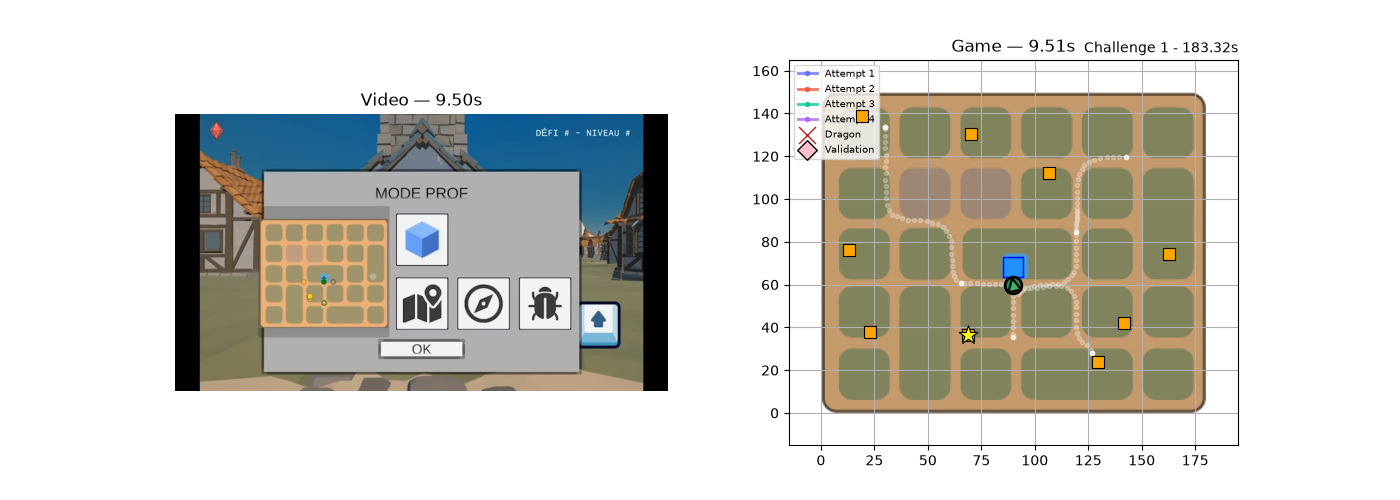

In [3]:
# ---------- CONFIG ---------- #
VIDEO_PATH = "../videos/video01.mp4"
MAP_IMAGE = "../images/map_level1.png"
VIDEO_OFFSET = 0.0

# ---------- VIDEO SETUP ---------- #
cap = cv2.VideoCapture(VIDEO_PATH)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
video_fps = cap.get(cv2.CAP_PROP_FPS)

cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
ret, first_frame = cap.read()
first_frame_rgb = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)

# ---------- ATTEMPT COLORS ---------- #
attempts = sorted(player_movement_df["attempt_number"].unique())
attempt_colors = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA',
                  '#FFA15A', '#19D3F3', '#FF6692', '#B6E880']

# ---------- EVENT STYLES ---------- #
verb_styles = {
    "attacks":   {"color": "firebrick",  "marker": "x",  "label": "Dragon",     "size": 150},
    "validates": {"color": "pink",       "marker": "D",  "label": "Validation",  "size": 100},
}
event_positions = {i: get_player_pos_for_time(t) for i, t in game_events_df["time"].items()}


# ---------- FIGURES ---------- #

# One under the other version
#fig_video, ax_video = plt.subplots(figsize=(6, 5))
#fig_game, ax_game = plt.subplots(figsize=(6, 5))

fig, (ax_video, ax_game) = plt.subplots(1, 2, figsize=(14, 5))

# --- Video ---
ax_video.axis('off')
img_display = ax_video.imshow(first_frame_rgb)
ax_video.set_title("Video")

# --- Game map ---
map_img_mpl = mpimg.imread(MAP_IMAGE)
ax_game.imshow(map_img_mpl, extent=map_coord, origin="upper", aspect="equal")
ax_game.set_xlim(map_extent[0], map_extent[1])
ax_game.set_ylim(map_extent[2], map_extent[3])
ax_game.grid(True)

# Trail (static)
ax_game.plot(x_list, z_list, 'o', color='white', alpha=0.25, markersize=3)

# POIs (static)
ax_game.scatter(
    buildings_df["world_pos_x"], buildings_df["world_pos_z"],
    marker='s', c='orange', s=80, edgecolors='black', linewidths=0.8, zorder=6
)

# Target building (static)
ax_game.scatter(
    [buildings_df.loc[target_building_id, "world_pos_x"]],
    [buildings_df.loc[target_building_id, "world_pos_z"]],
    marker='*', c='yellow', s=200, edgecolors='black', linewidths=0.8, zorder=6
)

# Cathedral (static)
ax_game.scatter([90], [68], marker='s', c='dodgerblue', s=200,
                edgecolors='blue', linewidths=1, zorder=6)

# --- Animated elements ---

# One path line per attempt
attempt_lines = {}
for j, attempt in enumerate(attempts):
    color = attempt_colors[j % len(attempt_colors)]
    line, = ax_game.plot([], [], '-o', color=color, markersize=3, linewidth=2,
                         label=f"Attempt {attempt}", alpha=0.8, zorder=7)
    attempt_lines[attempt] = line

# Current position
current, = ax_game.plot([], [], 'o', color='seagreen', markersize=12,
                        markeredgecolor='black', markeredgewidth=2, zorder=10)

# Rotation triangle
SIZE = 6
base_triangle = np.array([
    [0, SIZE/2],
    [-SIZE/2, -SIZE/2],
    [SIZE/2, -SIZE/2],
])
tri_patch = Polygon(base_triangle, closed=True, fc='mediumseagreen',
                    ec='black', lw=1.5, zorder=11)
tri_patch.set_visible(False)
ax_game.add_patch(tri_patch)

# Event scatter placeholders (one per verb)
event_scatters = {}
for verb, style in verb_styles.items():
    sc = ax_game.scatter([], [], marker=style["marker"], c=style["color"],
                         s=style["size"], edgecolors='black', linewidths=1,
                         zorder=8, label=style["label"])
    event_scatters[verb] = sc

ax_game.legend(loc='upper left', fontsize=7)

# Challenge annotation
ax_game.annotate(f"Challenge {challenge_id} - {challenge_duration:.2f}s",
                 xy=(1.0, 1.02), xycoords='axes fraction',
                 fontsize=10, ha='right')

# ---------- SHARED UPDATE ---------- #

def update(frame):
    # Video: convert game time to video frame
    game_time = time_list[frame]
    video_frame = int((game_time + VIDEO_OFFSET) * video_fps)
    video_frame = max(0, min(video_frame, total_frames - 1))
    cap.set(cv2.CAP_PROP_POS_FRAMES, video_frame)
    ret, vframe = cap.read()
    if ret:
        img_display.set_data(cv2.cvtColor(vframe, cv2.COLOR_BGR2RGB))
    ax_video.set_title(f"Video — {video_frame / video_fps:.2f}s")

    # Game — clamp to last available frame
    #game_frame = min(frame, len(x_list) - 1)

    # --- Game: attempt paths ---
    for attempt in attempts:
        mask = [j for j in range(frame + 1) if attempt_list[j] == attempt]
        attempt_lines[attempt].set_data(
            [x_list[j] for j in mask],
            [z_list[j] for j in mask]
        )

    # --- Game: current marker ---
    current.set_data([x_list[frame]], [z_list[frame]])

    # --- Game: triangle ---
    next_frame = min(frame + 1, len(x_list) - 1)
    angle = -rot_y_list[frame]
    rad = np.radians(angle)
    cos_a, sin_a = np.cos(rad), np.sin(rad)
    rotated = np.array([
        [v[0]*cos_a - v[1]*sin_a, v[0]*sin_a + v[1]*cos_a]
        for v in base_triangle
    ])
    rotated[:, 0] += x_list[next_frame]
    rotated[:, 1] += z_list[next_frame]
    tri_patch.set_xy(rotated)
    tri_patch.set_visible(True)

    # --- Game: events ---
    game_time = time_list[frame]
    for verb, style in verb_styles.items():
        mask = game_events_df[(game_events_df["verb"] == verb) & (game_events_df["time"] <= game_time)].index
        if len(mask) > 0:
            positions = np.array([event_positions[j] for j in mask])
            event_scatters[verb].set_offsets(positions)
        else:
            event_scatters[verb].set_offsets(np.empty((0, 2)))

    ax_game.set_title(f"Game — {game_time:.2f}s")

    fig.canvas.draw_idle()

    #fig_video.canvas.draw_idle()
    #fig_game.canvas.draw_idle()

# ---------- CONTROLS ---------- #

avg_step = (time_list[-1] - time_list[0]) / len(time_list) * 1000  # ~1000ms


offset_input = widgets.FloatText(value=VIDEO_OFFSET, description='Offset (s):',
                                 layout=widgets.Layout(width='200px'))

def on_offset_change(change):
    global VIDEO_OFFSET
    VIDEO_OFFSET = change['new']

offset_input.observe(on_offset_change, names='value')

play_btn = widgets.Play(value=0, min=0, max=len(x_list) - 1,
                        step=1, interval=int(avg_step))
slider = widgets.IntSlider(min=0, max=len(x_list) - 1, step=1,
                           value=0, description="Frame",
                           layout=widgets.Layout(width='70%'))

speed_dropdown = widgets.Dropdown(
    options=[('1x', 1), ('2x', 0.5), ('4x', 0.25), ('8x', 0.125)],
    value=1,
    description='Speed:',
    layout=widgets.Layout(width='150px')
)

def on_speed_change(change):
    play_btn.interval = int(avg_step * change['new'])

speed_dropdown.observe(on_speed_change, names='value')

widgets.jslink((play_btn, 'value'), (slider, 'value'))
widgets.interactive_output(update, {'frame': slider})

controls = widgets.HBox([play_btn, slider, offset_input, speed_dropdown])
display(controls)